In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


path='D:\\DATA\\Projets\\M1_EEG_Project\\' # specify the path to the folder containing the data file/

session='data' # specify the name of the session folder

filename='alpha_test.csv' # specify the name of the data file


data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame  

eeg_data=data.iloc[:, 1:9].to_numpy()  # select the EEG data columns (assuming they are in columns 1 to 8)
eeg_data = eeg_data.T

C:\Users\Nicolas Catz\AppData\Local\Temp\ipykernel_46020\3890713343.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(os.path.join(path, session, filename),delimiter='\\t',header=None) # read the data file into a pandas DataFrame


In [86]:
from scipy.signal import butter, filtfilt, iirnotch

fs = 250
print(f"Fréquence d'échantillonnage estimée : {fs:.2f} Hz")

def bandpass_filter(sig, low=1.0, high=40.0, fs=fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq=50.0, fs=fs, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)

Fréquence d'échantillonnage estimée : 250.00 Hz


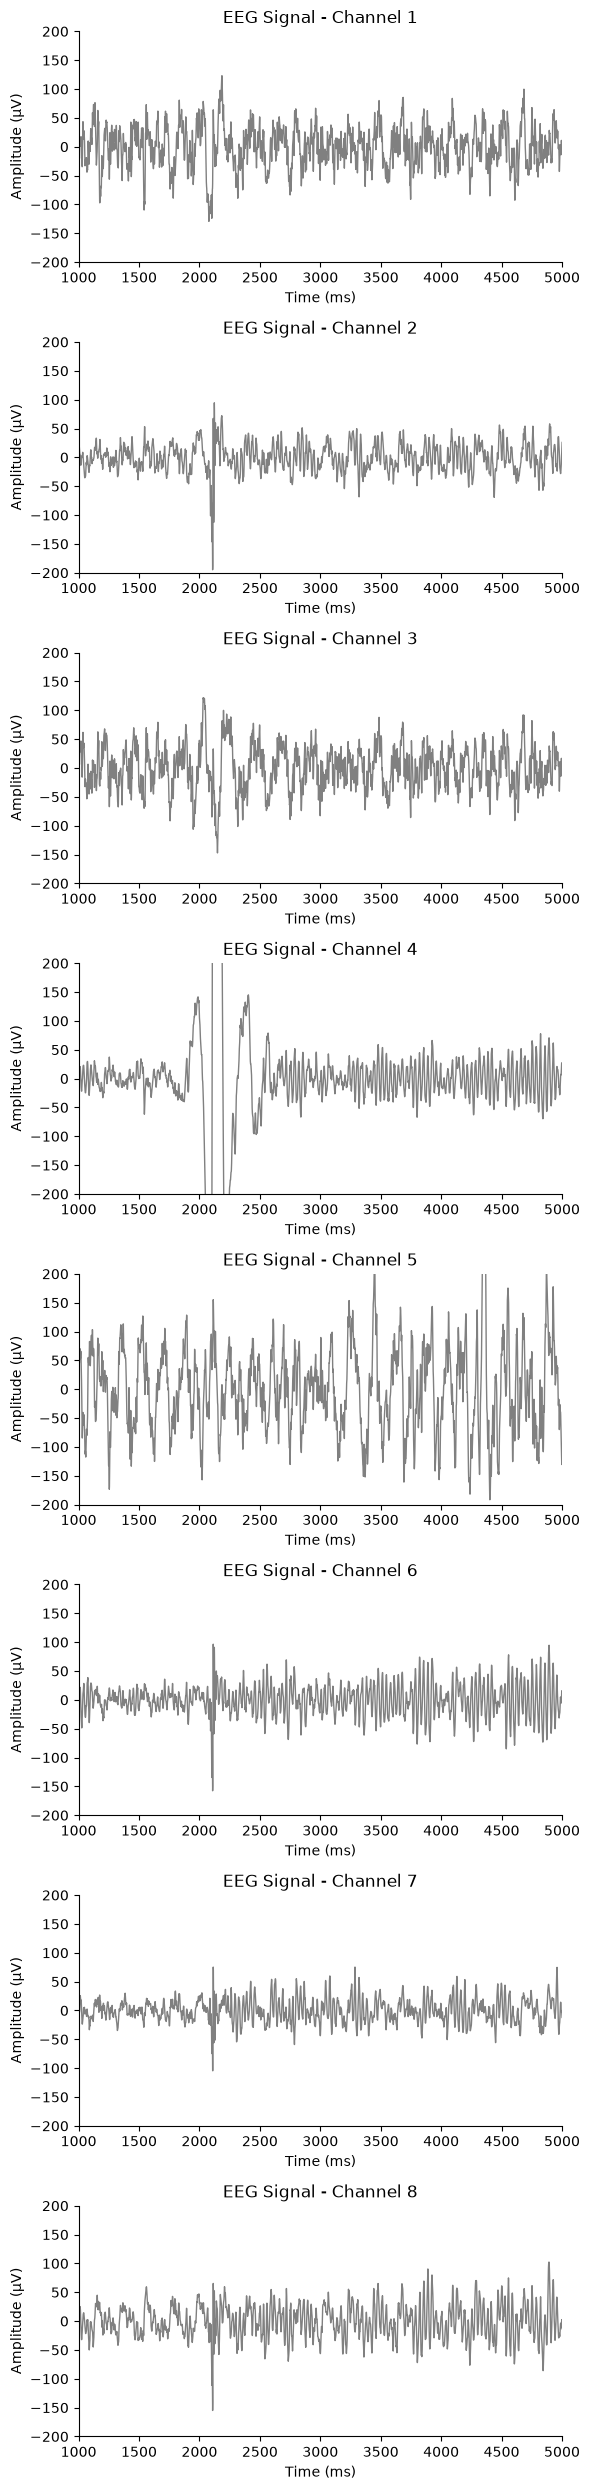

In [87]:
fig,axs=plt.subplots(8,1,figsize=(6,25))

for channel in range(0,8):  # Only process the first channel
    
    raw_signal = eeg_data[channel,0:-2]

    eeg_filtered = notch_filter(bandpass_filter(raw_signal))
    
    axs[channel].plot(eeg_filtered, color='gray', linewidth=1)
    axs[channel].set_title(f'EEG Signal - Channel {channel+1}')
    axs[channel].set_ylim(-200, 200)
    axs[channel].set_xlim(1000, 5000)
    axs[channel].set_xlabel('Time (ms)')
    axs[channel].set_ylabel('Amplitude (µV)')
    axs[channel].spines['top'].set_visible(False)
    axs[channel].spines['right'].set_visible(False)
    
plt.tight_layout()
    


## Analyse spectrale — densité de puissance (PSD)

Calcul de la densité spectrale de puissance (PSD) de chaque canal via la méthode de Welch, pour visualiser la puissance du signal EEG en fonction de la fréquence. La bande alpha (6-13 Hz) est mise en évidence — élargie par rapport aux 8-12 Hz théoriques pour tenir compte de la fréquence alpha individuelle, qui peut être plus basse (ex. ~7-8 Hz observés ici).

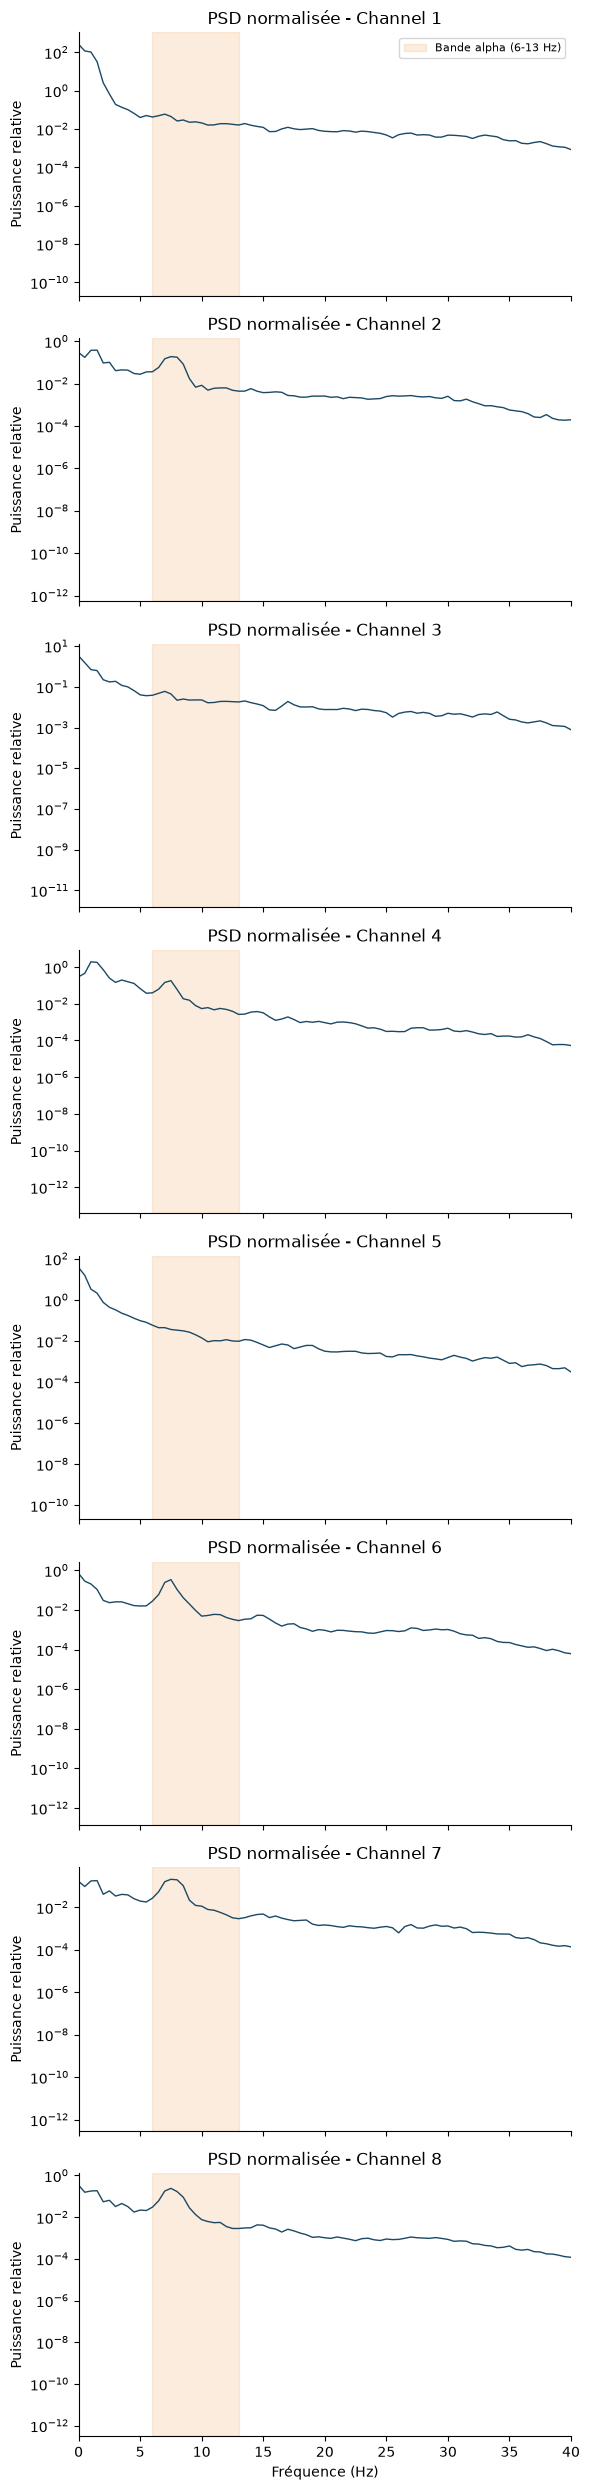

In [88]:
from scipy.signal import welch

alpha_band = (6, 13)  # bande de fréquence alpha élargie (fréquence alpha individuelle variable)
psd_band = (4, 40)    # bande utilisée pour normaliser (correspond au filtre passe-bande)

fig, axs = plt.subplots(8, 1, figsize=(6, 25), sharex=True)

alpha_power = []

for channel in range(0, 8):

    raw_signal = eeg_data[channel, 0:-2]
    eeg_filtered = notch_filter(bandpass_filter(raw_signal))

    freqs, psd = welch(eeg_filtered, fs=fs, nperseg=fs * 2)

    # normalisation : puissance relative (la PSD de chaque canal somme à 1 sur 4-40 Hz)
    norm_mask = (freqs >= psd_band[0]) & (freqs <= psd_band[1])
    psd_norm = psd / psd[norm_mask].sum()

    axs[channel].plot(freqs, psd_norm, color='#1B4965', linewidth=1)
    axs[channel].axvspan(*alpha_band, color='#F4A259', alpha=0.2, label='Bande alpha (6-13 Hz)')
    axs[channel].set_title(f'PSD normalisée - Channel {channel+1}')
    axs[channel].set_xlim(0, 40)
    axs[channel].set_yscale('log')
    axs[channel].set_ylabel('Puissance relative')
    axs[channel].spines['top'].set_visible(False)
    axs[channel].spines['right'].set_visible(False)

    alpha_mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power.append(psd_norm[alpha_mask].sum())

axs[0].legend(loc='upper right', fontsize=8)
axs[-1].set_xlabel('Fréquence (Hz)')

plt.tight_layout()
plt.show()

### Puissance alpha moyenne par canal

Résumé de la puissance moyenne dans la bande alpha (6-13 Hz) pour chaque canal, calculée à partir de la PSD ci-dessus.

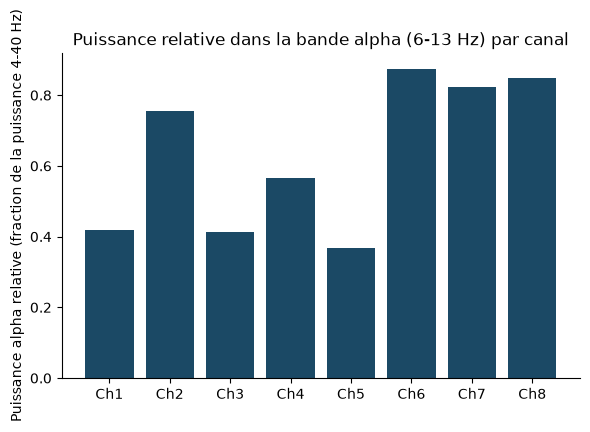

In [89]:
channels = [f'Ch{i+1}' for i in range(8)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(channels, alpha_power, color='#1B4965')
ax.set_ylabel('Puissance alpha relative (fraction de la puissance 4-40 Hz)')
ax.set_title('Puissance relative dans la bande alpha (6-13 Hz) par canal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Spectrogramme 3D — puissance en fonction du temps et de la fréquence

Représentation 3D (temps × fréquence × puissance) de chaque canal, calculée par fenêtres glissantes (spectrogramme de Welch). Permet de voir l'évolution de la puissance alpha (et des autres bandes) au cours de l'enregistrement, contrairement à la PSD globale ci-dessus.

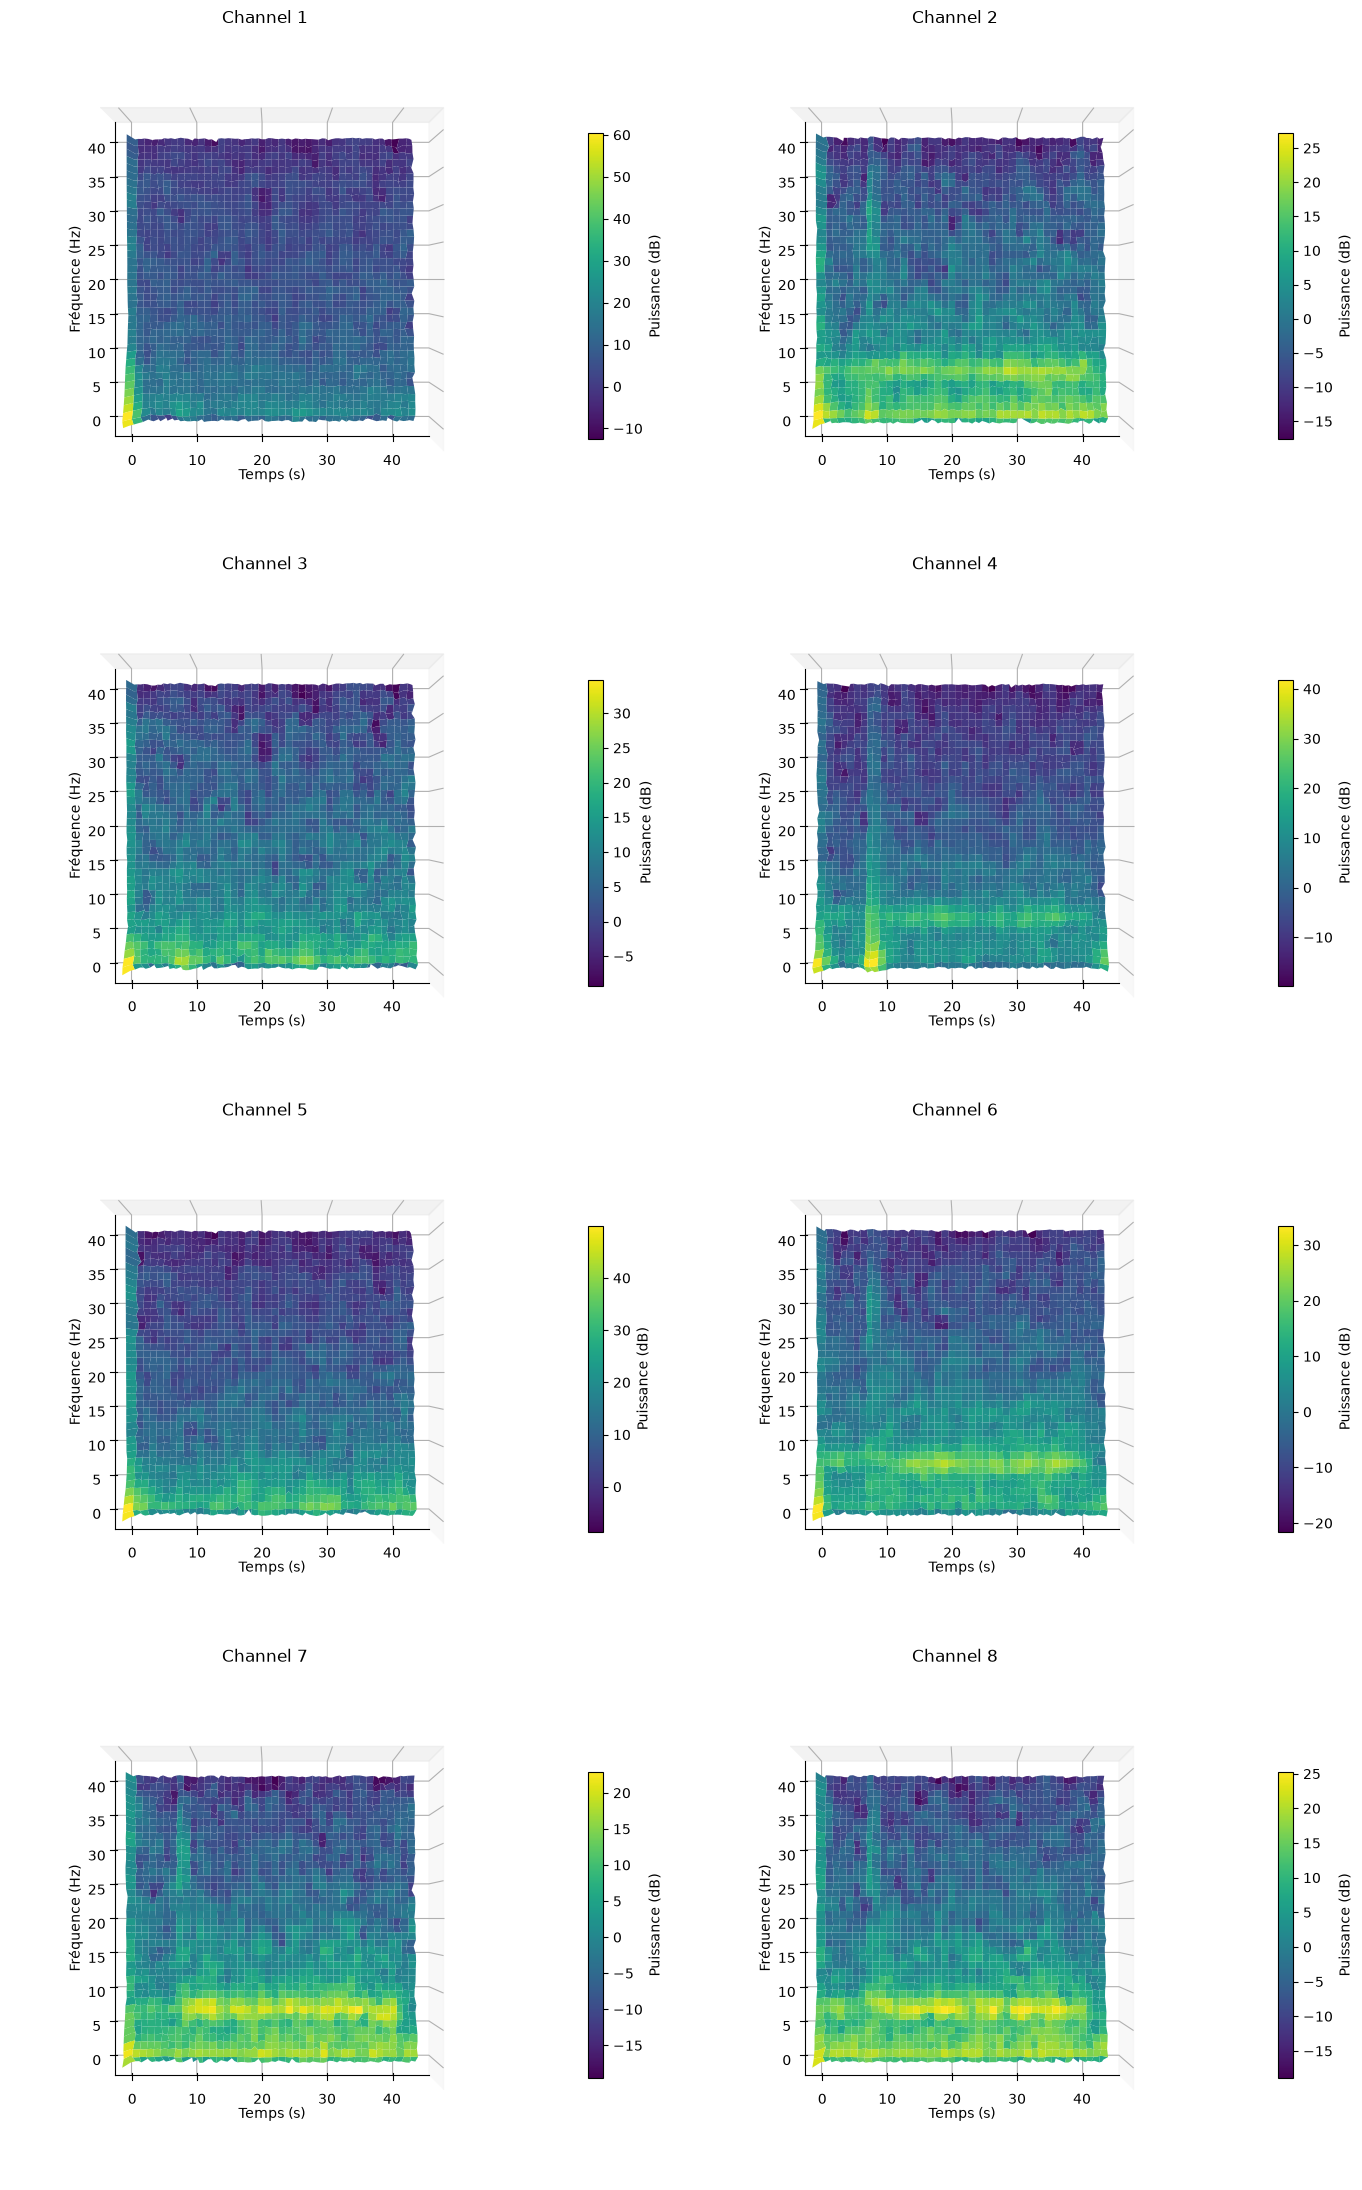

In [90]:
from scipy.signal import spectrogram
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (nécessaire pour projection='3d')

FREQ_MAX = 40  # Hz, borne supérieure affichée

fig = plt.figure(figsize=(14, 22))

for channel in range(0, 8):

    raw_signal = eeg_data[channel, 0:-2]
    eeg_filtered = notch_filter(bandpass_filter(raw_signal))

    freqs, times, Sxx = spectrogram(eeg_filtered, fs=fs, nperseg=fs, noverlap=fs // 2)

    freq_mask = freqs <= FREQ_MAX
    freqs_plot = freqs[freq_mask]
    Sxx_db = 10 * np.log10(Sxx[freq_mask] + 1e-12)  # échelle dB pour mieux voir les variations

    T, F = np.meshgrid(times, freqs_plot)

    ax = fig.add_subplot(4, 2, channel + 1, projection='3d')
    surf = ax.plot_surface(T, F, Sxx_db, cmap='viridis', linewidth=0, antialiased=True)
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label='Puissance (dB)')

    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Fréquence (Hz)')

    # masquer l'axe vertical (la couleur encode déjà la puissance)
    ax.set_zlabel('')
    ax.set_zticks([])
    ax.zaxis.line.set_visible(False)
    ax.zaxis.set_pane_color((1, 1, 1, 0))

    ax.view_init(elev=90, azim=-90)

plt.tight_layout()
plt.show()

## Spectrogramme 2D (imshow) — Channel 8

Signal EEG filtré et son spectrogramme (temps × fréquence × puissance), empilés en subplots avec le même axe temporel, pour le canal 8 uniquement.

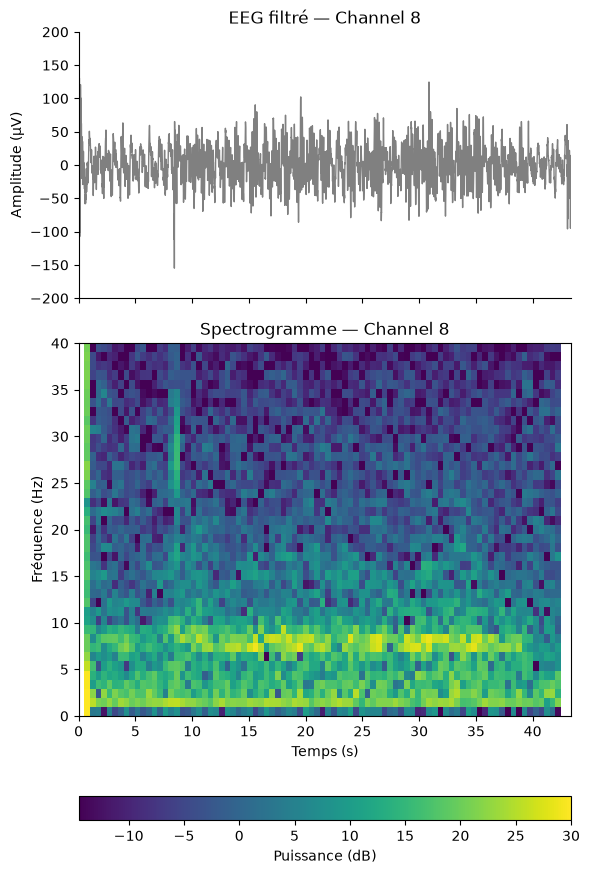

In [91]:
channel = 8  # canal à visualiser (1-indexé)

raw_signal = eeg_data[channel - 1, 0:-2]
eeg_filtered = notch_filter(bandpass_filter(raw_signal))

t = np.arange(len(eeg_filtered)) / fs

freqs, times, Sxx = spectrogram(eeg_filtered, fs=fs, nperseg=fs, noverlap=fs // 2)
freq_mask = freqs <= FREQ_MAX
freqs_plot = freqs[freq_mask]
Sxx_db = 10 * np.log10(Sxx[freq_mask] + 1e-12)

VMIN, VMAX = np.percentile(Sxx_db, [5, 95])  # ajuste ces deux valeurs (en dB) pour changer le contraste
VMAX =30

fig, axs = plt.subplots(2, 1, figsize=(6, 9), sharex=True, gridspec_kw={'height_ratios': [1, 2]})

axs[0].plot(t, eeg_filtered, color='gray', linewidth=1)
axs[0].set_title(f'EEG filtré — Channel {channel}')
axs[0].set_ylabel('Amplitude (µV)')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_xlim(t.min(), t.max())
axs[0].set_ylim(-200, 200)

im = axs[1].imshow(
    Sxx_db,
    aspect='auto',
    extent=[times.min(), times.max(), freqs_plot.min(), freqs_plot.max()],
    origin='lower',
    cmap='viridis',
    vmin=VMIN,
    vmax=VMAX,
)
axs[1].set_title(f'Spectrogramme — Channel {channel}')
axs[1].set_xlabel('Temps (s)')
axs[1].set_ylabel('Fréquence (Hz)')
fig.colorbar(im, ax=axs[1], orientation='horizontal', location='bottom', pad=0.15, label='Puissance (dB)')

plt.tight_layout()
plt.show()